# 2. Deploy CLM-v0.1-8B on an Amazon SageMaker AI real-time endpoint, then test and benchmark it

> **Note:** This is sample code for demonstration purposes only and is not intended for production use without
> additional security testing and review.

[CLM-v0.1-8B](https://huggingface.co/Contrastive-LM/CLM-v0.1-8B) is a contrastive "System One" model: it does
not generate text, it **scores** candidates (typed answers or free-form options) against a state.
It has two parts:

1. a frozen **Qwen3-8B** encoder that turns text into a 4096-d last-token embedding, served by **vLLM** in pooling mode, and
2. two small **projection heads** (75 MB together) from the `contrastive-lm` package, which turn those embeddings into scores.

Locally the project runs these as two servers (`vllm serve` and `clm-serve`). On SageMaker both run in **one
container**, the AWS vLLM Deep Learning Container (DLC), with no custom image:

```
InvokeEndpoint ──► /invocations  (code/model.py: CLM engine, heads on CPU)
                       │  POST 127.0.0.1:8080/v1/embeddings
                       ▼
                   vLLM 0.30  --runner pooling  Qwen3-8B bf16  (GPU)
```

The DLC loads `code/model.py` from the model artifact and lets it replace the default `/invocations` route;
`/ping` stays vLLM's health check.

**Instance:** Qwen3-8B in bf16 is 16.4 GB of weights, so 24 GB of GPU memory is the smallest that fits with room for a
KV cache. Quantizing is not an option: the heads are trained on bf16 Qwen3-8B embeddings. This notebook asks for five
single-GPU types, cheapest first:

| Priority | Instance | GPU | GPU memory | us-east-1 $/h |
|---|---|---|---|---|
| 1 | `ml.g6.xlarge` | NVIDIA L4 | 24 GB | **1.127** |
| 2 | `ml.g6.2xlarge` | NVIDIA L4 | 24 GB | 1.222 |
| 3 | `ml.g5.xlarge` | NVIDIA A10G | 24 GB | 1.408 |
| 4 | `ml.g5.2xlarge` | NVIDIA A10G | 24 GB | 1.515 |
| 5 | `ml.g6e.xlarge` | NVIDIA L40S | 48 GB | 2.605 |

All five hold the model, so the endpoint takes the cheapest one that has capacity. Single-GPU 24 GB instances are the
sweet spot: `ml.g4dn.xlarge` ($0.736) has 16 GB and no bf16 support, so it cannot run this model at all, while larger
instances pay for GPU memory and tensor parallelism an 8B encoder does not need. **Small GPU instances run out of
capacity often**: `ml.g6.xlarge` and `ml.g5.xlarge` each failed for us with `InsufficientInstanceCapacity` while writing
this sample, which is exactly why the endpoint asks for five.

**Run time:** about 45 minutes, most of it the first artifact upload (16 GB) and the endpoint start (10 to 17 minutes).
**Cost:** $1.13 to $2.61 per endpoint hour depending on which pool has capacity, plus S3 storage. The clean-up cell at
the end is commented out by default: uncomment and run it when you are done, or the endpoint keeps billing.

## 1. Configuration
Every external input is pinned: model revisions, the CLM source commit, and the container image tag.

In [1]:
import json, math, time, collections, uuid, hashlib, shutil, tarfile, concurrent.futures as cf
from pathlib import Path
import boto3, numpy as np, pandas as pd, requests
from botocore.config import Config
from botocore.exceptions import ClientError

REGION = "us-east-1"
# Instance pools, cheapest first: SageMaker falls back to the next type when one has no capacity (max 5 pools).
PRICE_PER_HOUR = {"ml.g6.xlarge": 1.1267, "ml.g6.2xlarge": 1.222, "ml.g5.xlarge": 1.408,
                  "ml.g5.2xlarge": 1.515, "ml.g6e.xlarge": 2.6054}   # SageMaker on-demand, USD (same in us-east-1/us-west-2)
INSTANCE_TYPES = sorted(PRICE_PER_HOUR, key=PRICE_PER_HOUR.get)

ENCODER_ID, ENCODER_REV = "Qwen/Qwen3-8B", "b968826d9c46dd6066d109eabc6255188de91218"
HEADS_ID, HEADS_REV = "Contrastive-LM/CLM-v0.1-8B", "e939398d4556fcd9400c76fa8c5a513202f42b0a"
CLM_SRC_COMMIT = "bb42c6c5bf914fd449bed2f6ca65be80602cb1f7"          # github.com/Contrastive-LM/CLM  # pragma: allowlist secret
IMAGE = f"763104351884.dkr.ecr.{REGION}.amazonaws.com/vllm:0.30.0-gpu-py312-cu130-ubuntu24.04-sagemaker-v1.3"
INFERENCE_AMI = "al2023-ami-sagemaker-inference-gpu-4-1"             # NVIDIA 580 driver, needed by CUDA 13 images

NAME = "clm-8b"            # one deployment per account and Region: the weights, artifact and role are shared
ROLE_NAME = "clm-8b-sagemaker-execution"
EXISTING_ROLE_ARN = None   # set to an existing SageMaker execution role ARN to use it instead of creating one
ROLE_TAG = {"Key": "created-by", "Value": "clm-8b-sagemaker-sample"}

session = boto3.Session(region_name=REGION)
account = session.client("sts").get_caller_identity()["Account"]
BUCKET = f"sagemaker-{REGION}-{account}"
WEIGHTS = f"clm-8b/weights/{ENCODER_REV[:8]}/"   # the Qwen3-8B files, stored once; each artifact copies them
sm = session.client("sagemaker")
s3 = session.client("s3", config=Config(max_pool_connections=64))   # 4 files x 16 parts in flight
# The benchmark measures every call as sent, so its client never retries; the correctness and quality checks
# use one that retries transient errors (throttling, a dropped connection); invoke() below also retries the
# handler's own 503.
smr = session.client("sagemaker-runtime", config=Config(max_pool_connections=128, read_timeout=70,
                                                        retries={"total_max_attempts": 1, "mode": "standard"}))
smr_checks = session.client("sagemaker-runtime", config=Config(max_pool_connections=16, read_timeout=70,
                                                               retries={"max_attempts": 4, "mode": "standard"}))
def show(x):
    """Printable form of a value with the account ID masked, so saved outputs do not leak it."""
    return str(x).replace(account, "<account-id>")

print(f"region {REGION}  bucket {show(BUCKET)}  instance pools {INSTANCE_TYPES}")

region us-east-1  bucket sagemaker-us-east-1-<account-id>  instance pools ['ml.g6.xlarge', 'ml.g6.2xlarge', 'ml.g5.xlarge', 'ml.g5.2xlarge', 'ml.g6e.xlarge']


## 2. Execution role (least privilege)
The endpoint only needs to read its artifact prefix (in this account's bucket only), pull the DLC image, and write
logs and metrics. Skipped if you set `EXISTING_ROLE_ARN`.

In [2]:
iam = session.client("iam")
# Decided from the configuration each time, so re-running this cell (say after the clean-up) creates the role again.
OURS = EXISTING_ROLE_ARN is None
ROLE_ARN = EXISTING_ROLE_ARN
if OURS:
    # aws:SourceAccount stops other accounts' SageMaker resources from using this role (confused deputy).
    trust = {"Version": "2012-10-17", "Statement": [{"Effect": "Allow", "Action": "sts:AssumeRole",
             "Principal": {"Service": "sagemaker.amazonaws.com"},
             "Condition": {"StringEquals": {"aws:SourceAccount": account}}}]}
    policy = {"Version": "2012-10-17", "Statement": [
        {"Effect": "Allow", "Action": "s3:GetObject", "Resource": f"arn:aws:s3:::{BUCKET}/clm-8b/*",
         "Condition": {"StringEquals": {"s3:ResourceAccount": account}}},
        {"Effect": "Allow", "Action": "s3:ListBucket", "Resource": f"arn:aws:s3:::{BUCKET}",
         "Condition": {"StringLike": {"s3:prefix": ["clm-8b/*"]},
                       "StringEquals": {"s3:ResourceAccount": account}}},
        {"Effect": "Allow", "Action": "ecr:GetAuthorizationToken", "Resource": "*"},
        {"Effect": "Allow", "Action": ["ecr:BatchGetImage", "ecr:GetDownloadUrlForLayer",
                                       "ecr:BatchCheckLayerAvailability"],
         "Resource": f"arn:aws:ecr:{REGION}:763104351884:repository/vllm"},
        {"Effect": "Allow", "Action": ["logs:CreateLogGroup", "logs:CreateLogStream", "logs:PutLogEvents",
                                       "logs:DescribeLogStreams"],
         "Resource": f"arn:aws:logs:{REGION}:{account}:log-group:/aws/sagemaker/*"},
        {"Effect": "Allow", "Action": "cloudwatch:PutMetricData", "Resource": "*",
         "Condition": {"StringLike": {"cloudwatch:namespace": ["/aws/sagemaker/*", "AWS/SageMaker*"]}}}]}
    # The role is tagged when created, so a re-run updates only a role this notebook made (and clean-up deletes only
    # that one). An existing role without the tag belongs to someone else: the cell stops instead of changing it.
    try:
        ROLE_ARN = iam.create_role(RoleName=ROLE_NAME, AssumeRolePolicyDocument=json.dumps(trust),
                                   Description="CLM-8B SageMaker endpoint", Tags=[ROLE_TAG])["Role"]["Arn"]
    except iam.exceptions.EntityAlreadyExistsException:
        if ROLE_TAG not in iam.list_role_tags(RoleName=ROLE_NAME)["Tags"]:
            raise SystemExit(f"a role named {ROLE_NAME} already exists and was not created by this notebook: "
                             "set EXISTING_ROLE_ARN to use it as it is, or change ROLE_NAME")
        ROLE_ARN = iam.get_role(RoleName=ROLE_NAME)["Role"]["Arn"]
        iam.update_assume_role_policy(RoleName=ROLE_NAME, PolicyDocument=json.dumps(trust))
    iam.put_role_policy(RoleName=ROLE_NAME, PolicyName="clm-8b-endpoint", PolicyDocument=json.dumps(policy))
    time.sleep(15)   # IAM is eventually consistent: let the role and its policy propagate before SageMaker uses them
print("execution role:", show(ROLE_ARN))

execution role: arn:aws:iam::<account-id>:role/clm-8b-sagemaker-execution


## 3. Build the model artifact in S3
One **uncompressed** S3 prefix, mounted read-only at `/opt/ml/model`. Uncompressed means no tar to extract at start-up, and
because the weights come from S3 the endpoint runs with **network isolation** (no internet, no Hugging Face access).
The prefix name includes a hash of `code/`, so changing the handler produces a new artifact instead of editing a live one.

```
/opt/ml/model/
├── config.json, tokenizer*, model-0000X-of-00005.safetensors   Qwen3-8B (vLLM loads this)
└── code/
    ├── model.py            the /invocations handler (this repo)
    ├── clm/                contrastive-lm engine, pinned commit
    └── CLM_v0.1-8B.pt      projection heads, pinned revision
```

The weights are uploaded once and copied inside S3 into each artifact, and every step skips files that are already
there, so re-running is cheap. Each new version of `code/` costs one more 16.4 GB copy (a server-side copy of about
30 s, and about $0.38 a month of S3 Standard storage until the clean-up section deletes it).

In [3]:
from fnmatch import fnmatch
from huggingface_hub import HfApi, hf_hub_download, snapshot_download
from boto3.s3.transfer import TransferConfig

BUILD = Path("build")
OWNER = {"ExpectedBucketOwner": account}   # every S3 call fails if the bucket belongs to someone else

# The SageMaker default bucket name is predictable, so check that this account owns it, and create it if missing.
try:
    s3.head_bucket(Bucket=BUCKET, **OWNER)
except ClientError as e:
    if e.response["Error"]["Code"] not in ("404", "NoSuchBucket"):
        raise SystemExit(f"{show(BUCKET)} exists but is not usable by this account ({e.response['Error']['Code']})")
    s3.create_bucket(Bucket=BUCKET, **({} if REGION == "us-east-1" else
                                       {"CreateBucketConfiguration": {"LocationConstraint": REGION}}))
    s3.put_public_access_block(Bucket=BUCKET, PublicAccessBlockConfiguration={
        "BlockPublicAcls": True, "IgnorePublicAcls": True, "BlockPublicPolicy": True, "RestrictPublicBuckets": True})
    s3.put_bucket_policy(Bucket=BUCKET, Policy=json.dumps({"Version": "2012-10-17", "Statement": [{
        "Sid": "DenyInsecureTransport", "Effect": "Deny", "Principal": "*", "Action": "s3:*",
        "Resource": [f"arn:aws:s3:::{BUCKET}", f"arn:aws:s3:::{BUCKET}/*"],
        "Condition": {"Bool": {"aws:SecureTransport": "false"}}}]}))      # TLS only
    print("created", show(BUCKET))

# A bucket encrypted with a customer KMS key also needs kms:Decrypt for the endpoint to read the artifact.
rules = []
try:
    rules = s3.get_bucket_encryption(Bucket=BUCKET, **OWNER)["ServerSideEncryptionConfiguration"]["Rules"]
except ClientError as e:
    if e.response["Error"]["Code"] != "ServerSideEncryptionConfigurationNotFoundError":
        raise
# S3 accepts a key ID, alias or ARN here; IAM needs the key ARN, so resolve it.
kms_keys = [session.client("kms").describe_key(KeyId=r["ApplyServerSideEncryptionByDefault"]["KMSMasterKeyID"])
            ["KeyMetadata"]["Arn"] for r in rules
            if r.get("ApplyServerSideEncryptionByDefault", {}).get("KMSMasterKeyID")]
if kms_keys and OURS:
    iam.put_role_policy(RoleName=ROLE_NAME, PolicyName="clm-8b-kms", PolicyDocument=json.dumps({
        "Version": "2012-10-17", "Statement": [{"Effect": "Allow", "Action": "kms:Decrypt", "Resource": kms_keys,
        "Condition": {"StringEquals": {"kms:ViaService": f"s3.{REGION}.amazonaws.com"}}}]}))
    time.sleep(10)
if kms_keys and not OURS:
    print("bucket uses SSE-KMS: make sure your EXISTING_ROLE_ARN may kms:Decrypt with", show(kms_keys))
else:
    algos = sorted({r.get("ApplyServerSideEncryptionByDefault", {}).get("SSEAlgorithm", "AES256") for r in rules})
    print("bucket encryption:", ", ".join(algos) or "AES256",
          "(kms:Decrypt granted to the role)" if kms_keys else "(no customer managed key)")

def s3_objects(prefix):
    return [o for p in s3.get_paginator("list_objects_v2").paginate(Bucket=BUCKET, Prefix=prefix, **OWNER)
            for o in p.get("Contents", [])]

# Qwen3-8B weights (16.4 GB), stored once under WEIGHTS. Every expected file must be there with the right size,
# or the missing ones are downloaded and uploaded.
WEIGHT_PATTERNS = ["*.json", "*.safetensors", "merges.txt", "LICENSE"]
expected = {f.rfilename: f.size for f in HfApi().model_info(ENCODER_ID, revision=ENCODER_REV, files_metadata=True).siblings
            if any(fnmatch(f.rfilename, pat) for pat in WEIGHT_PATTERNS)}
have = {o["Key"][len(WEIGHTS):]: o["Size"] for o in s3_objects(WEIGHTS)}
missing = sorted(name for name, size in expected.items() if have.get(name) != size)
cfg = TransferConfig(multipart_chunksize=64 * 2**20, max_concurrency=16)
t0 = time.time()
if missing:
    snapshot_download(ENCODER_ID, revision=ENCODER_REV, local_dir=BUILD / "weights", allow_patterns=missing)
    with cf.ThreadPoolExecutor(4) as ex:         # several files at once, each in parallel parts
        list(ex.map(lambda name: s3.upload_file(str(BUILD / "weights" / name), BUCKET, WEIGHTS + name,
                                                Config=cfg, ExtraArgs=OWNER), missing))
print(f"weights: {len(expected)} files, {sum(expected.values()) / 1e9:.2f} GB, {len(missing)} uploaded in this run")

# code/: the handler, the clm package from the pinned source commit (minus its web UI) and the heads
# Downloads are cached under build/ (pinned, so they never go stale); build/code is rebuilt from them every run,
# so files from an earlier run (an old head, a removed module) never ship.
heads = Path(hf_hub_download(HEADS_ID, "CLM_v0.1-8B.pt", revision=HEADS_REV, local_dir=BUILD / "heads"))
tarball = BUILD / f"clm-src-{CLM_SRC_COMMIT[:12]}.tar.gz"
if not tarball.exists() or not tarfile.is_tarfile(tarball):          # a cut-off earlier download is redone
    r = requests.get(f"https://codeload.github.com/Contrastive-LM/CLM/tar.gz/{CLM_SRC_COMMIT}", timeout=60)
    r.raise_for_status()
    part = tarball.with_suffix(".part")
    part.write_bytes(r.content)
    part.replace(tarball)                        # appears only once complete
shutil.rmtree(BUILD / "code", ignore_errors=True)
(BUILD / "code").mkdir(parents=True)
shutil.copy2(heads, BUILD / "code" / heads.name)
with tarfile.open(tarball) as src:
    for m in src.getmembers():
        rel = m.name.split("/", 1)[1] if "/" in m.name else ""
        if rel.startswith("src/clm/") and m.isfile() and "/static/" not in rel:
            out = (BUILD / "code" / rel[len("src/"):]).resolve()
            if not out.is_relative_to((BUILD / "code").resolve()):     # never write outside build/code
                raise RuntimeError(f"unexpected path in the source archive: {m.name}")
            out.parent.mkdir(parents=True, exist_ok=True)
            out.write_bytes(src.extractfile(m).read())
for f in Path("code").iterdir():              # the handler, plus any extra *.pt heads you add to code/
    if f.is_file() and (f.name == "model.py" or f.suffix == ".pt"):
        if f.name == heads.name or f.stem in ("clm-latest", "clm-raw"):   # the pinned heads, or a reserved model name
            raise SystemExit(f"code/{f.name} has a name the endpoint already uses: rename it to serve it as its own model")
        shutil.copy2(f, BUILD / "code" / f.name)
code_files = sorted(f for f in (BUILD / "code").rglob("*") if f.is_file())

# The artifact prefix includes a hash of code/, so a changed handler gets a new prefix and a running
# endpoint never mixes two handler versions (S3 keys are never overwritten in place).
digest = hashlib.sha256()
for f in code_files:
    digest.update(f.relative_to(BUILD).as_posix().encode() + b"\0" + f.read_bytes())
PREFIX = f"clm-8b/{ENCODER_REV[:8]}-{HEADS_REV[:8]}-{digest.hexdigest()[:10]}/"
have = {o["Key"][len(PREFIX):]: o["Size"] for o in s3_objects(PREFIX)}
with cf.ThreadPoolExecutor(4) as ex:             # server-side copies of missing or wrong-size files
    list(ex.map(lambda name: s3.copy({"Bucket": BUCKET, "Key": WEIGHTS + name}, BUCKET, PREFIX + name,
                                     Config=cfg, ExtraArgs=OWNER), [n for n, size in expected.items() if have.get(n) != size]))
for f in code_files:
    rel = f.relative_to(BUILD).as_posix()
    if have.get(rel) != f.stat().st_size:
        s3.upload_file(str(f), BUCKET, PREFIX + rel, Config=cfg, ExtraArgs=OWNER)
objects = s3_objects(PREFIX)
print(f"artifact {show(f's3://{BUCKET}/{PREFIX}')}: {len(objects)} objects, "
      f"{sum(o['Size'] for o in objects) / 1e9:.2f} GB ({time.time() - t0:.0f} s)")
print(sorted(f.relative_to(BUILD).as_posix() for f in code_files))

bucket encryption: AES256 (no customer managed key)
weights: 13 files, 16.40 GB, 0 uploaded in this run


artifact s3://sagemaker-us-east-1-<account-id>/clm-8b/b968826d-e939398d-b865eced6a/: 24 objects, 16.47 GB (9 s)
['code/CLM_v0.1-8B.pt', 'code/clm/__init__.py', 'code/clm/cache.py', 'code/clm/client.py', 'code/clm/embedder.py', 'code/clm/engine.py', 'code/clm/heads.py', 'code/clm/py.typed', 'code/clm/schema.py', 'code/clm/server.py', 'code/model.py']


## 4. Deploy the endpoint

| Setting | Value | Why |
|---|---|---|
| `SM_VLLM_RUNNER` | `pooling` | serve Qwen3-8B as an embedding model: last-token pooling + L2 normalise, which is what the heads were trained on |
| `SM_VLLM_MAX_MODEL_LEN` | `2048` | CLM's context length; the handler truncates to the same 2048 tokens |
| `SM_VLLM_SERVED_MODEL_NAME` | `qwen3-8b` | the name the CLM embedder asks for |
| `SAGEMAKER_MODEL_PATH` | `/opt/ml/model/code/` | where the DLC looks for the `model.py` handler |
| `CLM_DEVICE` | `cpu` | heads on CPU, so the whole GPU memory budget stays with vLLM |
| network isolation | on | the container has no internet; everything it needs is in the artifact |
| `InstancePools` | five types, cheapest first | GPU capacity is often short; SageMaker falls back to the next type instead of failing |
| routing | least outstanding requests | recommended with instance pools; sends each request to the least busy instance |
| start-up timeouts | 1200 s | 16 GB of weights plus a 22 GB image need more than the 8-minute default |

vLLM's defaults are kept otherwise: bf16, prefix caching (on by default for last-token pooling), piecewise CUDA
graphs, and `gpu-memory-utilization 0.9`. One default is worth keeping on purpose: **do not raise
`max_num_batched_tokens`**. In a separate experiment on ml.g5.xlarge (an earlier handler and a client in another
Region, so not comparable with section 7), raising it from the 2048 default cost throughput on the `rank` workload
at 64 concurrent requests: 35.6 req/s at 2048, 25.4 at 8192, 21.9 at 16384.
The KV cache on a 24 GB GPU holds about 24,000 tokens, so larger prefill batches make each step longer without
running more requests at once.

In [4]:
ENV = {
    "SM_VLLM_RUNNER": "pooling",
    "SM_VLLM_MAX_MODEL_LEN": "2048",
    "SM_VLLM_SERVED_MODEL_NAME": "qwen3-8b",
    "SAGEMAKER_MODEL_PATH": "/opt/ml/model/code/",
    "CLM_DEVICE": "cpu",
    # Keep idle connections open longer than SageMaker's front end reuses them (vLLM's default is 5 s), so a
    # request never lands on a connection the server has just closed.
    "VLLM_HTTP_TIMEOUT_KEEP_ALIVE": "75",
    # The vector cache, in host RAM: 256 MiB holds about 115,000 head vectors and 2,000 raw clm-raw vectors. Each
    # row is keyed by its full text (up to 32 KB), also in host RAM and outside this budget, so a larger cache can
    # run a long-lived endpoint out of memory: allow up to rows x your typical text size. The handler runs clm-raw
    # requests one at a time and caps each at the raw pool's size, so none evicts another's rows.
    "CLM_ACTION_CACHE": "256MiB",
}
def describe(call, **kw):
    """The resource's description, or None when it does not exist."""
    try:
        return call(**kw)
    except ClientError as e:
        if e.response["Error"]["Code"] == "ValidationException":     # SageMaker's "could not find"
            return None
        raise

# One read of each resource. Re-running this cell resumes an endpoint that is Creating, InService or Updating
# (after a kernel restart, when the wait below ran out, or while autoscaling or SageMaker maintenance acts), provided it was deployed
# with this run's artifact, image, environment, role, network isolation, pools and AMI. Anything else needs the
# part 1 of the clean-up section first.
live = {"endpoint": describe(sm.describe_endpoint, EndpointName=NAME),
        "endpoint config": describe(sm.describe_endpoint_config, EndpointConfigName=NAME),
        "model": describe(sm.describe_model, ModelName=NAME)}
# NAME is generic, so never resume, or point the clean-up at, a resource this notebook did not create (tagged ROLE_TAG).
arn_keys = {"endpoint": "EndpointArn", "endpoint config": "EndpointConfigArn", "model": "ModelArn"}
foreign = [k for k, d in live.items() if d and ROLE_TAG not in sm.list_tags(ResourceArn=d[arn_keys[k]])["Tags"]]
if foreign:
    raise SystemExit(f"{NAME}: the {', '.join(foreign)} of that name was not created by this notebook; "
                     "remove it yourself or change NAME")
resume = bool(live["endpoint"]) and live["endpoint"]["EndpointStatus"] in ("Creating", "InService", "Updating",
                                                                         "SystemUpdating")
if resume:
    c = (live["model"] or {}).get("PrimaryContainer", {})
    v = ((live["endpoint config"] or {}).get("ProductionVariants") or [{}])[0]
    pools = [p["InstanceType"] for p in sorted(v.get("InstancePools", []), key=lambda p: p["Priority"])]
    if live["endpoint"].get("EndpointConfigName") != NAME:
        raise SystemExit(f"{NAME} now runs endpoint config {live['endpoint'].get('EndpointConfigName')!r}, not the one "
                         "this notebook creates: run part 1 of the clean-up section, then deploy again")
    m = live["model"] or {}
    if (c.get("ModelDataSource", {}).get("S3DataSource", {}).get("S3Uri"), c.get("Image"), c.get("Environment", {}),
            m.get("ExecutionRoleArn"), m.get("EnableNetworkIsolation"), pools, v.get("InferenceAmiVersion"),
            v.get("VariantInstanceProvisionTimeoutInSeconds"), v.get("RoutingConfig", {}).get("RoutingStrategy"),
            v.get("ContainerStartupHealthCheckTimeoutInSeconds"), v.get("ModelDataDownloadTimeoutInSeconds")) != (
            f"s3://{BUCKET}/{PREFIX}", IMAGE, ENV, ROLE_ARN, True, INSTANCE_TYPES, INFERENCE_AMI,
            600, "LEAST_OUTSTANDING_REQUESTS", 1200, 1200):
        raise SystemExit(f"{NAME} is live with a different configuration than this run: "
                         "run part 1 of the clean-up section, then deploy again")
elif any(live.values()):
    raise SystemExit(f"{NAME}: {', '.join(k for k, v in live.items() if v)} from an earlier run still exist: "
                     "run part 1 of the clean-up section first")

if not resume:
    sm.create_model(
        ModelName=NAME, ExecutionRoleArn=ROLE_ARN, EnableNetworkIsolation=True, Tags=[ROLE_TAG],
        PrimaryContainer={"Image": IMAGE, "Environment": ENV,
                          "ModelDataSource": {"S3DataSource": {"S3Uri": f"s3://{BUCKET}/{PREFIX}",
                                                               "S3DataType": "S3Prefix", "CompressionType": "None"}}})
    sm.create_endpoint_config(
        EndpointConfigName=NAME, Tags=[ROLE_TAG],
        ProductionVariants=[{"VariantName": "AllTraffic", "ModelName": NAME, "InitialInstanceCount": 1,
                             "InstancePools": [{"InstanceType": t, "Priority": i + 1} for i, t in enumerate(INSTANCE_TYPES)],
                             "VariantInstanceProvisionTimeoutInSeconds": 600,   # per pool, before trying the next one
                             "RoutingConfig": {"RoutingStrategy": "LEAST_OUTSTANDING_REQUESTS"},
                             "InferenceAmiVersion": INFERENCE_AMI,
                             "ContainerStartupHealthCheckTimeoutInSeconds": 1200,
                             "ModelDataDownloadTimeoutInSeconds": 1200}])
    sm.create_endpoint(EndpointName=NAME, EndpointConfigName=NAME, Tags=[ROLE_TAG])
# Worst case: every pool waits its full provisioning window, then the download and health-check windows.
deadline = time.time() + 600 * len(INSTANCE_TYPES) + 1200 + 1200 + 600
t0 = time.time()
# An endpoint being created or updated (autoscaling, maintenance) is waited for, so the checks below see it settled.
while (ep := sm.describe_endpoint(EndpointName=NAME))["EndpointStatus"] in ("Creating", "Updating", "SystemUpdating") \
        and time.time() < deadline:
    time.sleep(30)
if ep["EndpointStatus"] in ("Creating", "Updating", "SystemUpdating"):
    raise SystemExit(f"{NAME} is still {ep['EndpointStatus']} after {(time.time() - t0) / 60:.0f} min. It may still succeed: "
                     "re-run this cell later to keep waiting before deciding to clean up.")
if ep["EndpointStatus"] != "InService":
    raise SystemExit(f"endpoint {ep['EndpointStatus']}: {show(ep.get('FailureReason', ''))}\nIf this is "
                     "InsufficientInstanceCapacity, every pool was full: run only part 1 of the clean-up section (the "
                     "endpoint, endpoint config and model; keep the S3 artifact and role), then retry later, add "
                     "another type to PRICE_PER_HOUR (at most 5 pools), or try another Region.")
pools = ep["ProductionVariants"][0]["InstancePools"]
serving = [p["InstanceType"] for p in pools for _ in range(p.get("CurrentInstanceCount") or 0)]
if len(serving) != 1:     # sections 7-10 measure and price one instance
    raise SystemExit(f"{NAME} runs {len(serving)} instances ({serving}); the benchmark and cost sections measure "
                     "one. Scale the variant to 1 instance (remove autoscaling) and re-run this cell.")
INSTANCE_TYPE = serving[0]
print(f"{NAME} InService after {(time.time() - t0) / 60:.1f} min on {INSTANCE_TYPE}  {pools}")

clm-8b InService after 11.5 min on ml.g5.2xlarge  [{'InstanceType': 'ml.g5.2xlarge', 'CurrentInstanceCount': 1}]


## 5. Invoke it
The body's `op` picks the CLM call, since a SageMaker endpoint only exposes `/invocations`.
The two requests below are the examples from the model card. The expected values come from an independent
reference run of the same checkpoint (Hugging Face Transformers, Qwen3-8B bf16 on CPU, last-token pooling):
`billing` 0.988, urgency 0.82, frustration 2.00, the Moon at 0.994. The endpoint computes in bf16 on a GPU, and the
result also depends on how vLLM batches the request with others; across our runs urgency came out between 0.827 and
0.851. The check allows 0.05. A broken deployment (wrong pooling, wrong revision, missing heads) misses by far more:
the department question, for one, flips to the wrong answer. (The model card prints different example numbers, such as
`billing` 0.939; they do not come from the published `CLM_v0.1-8B.pt` on Qwen3-8B.)

In [5]:
def invoke(body: dict) -> dict:
    for attempt in range(4):
        try:
            r = smr_checks.invoke_endpoint(EndpointName=NAME, ContentType="application/json", Body=json.dumps(body))
            return json.loads(r["Body"].read())
        except smr_checks.exceptions.ModelError as e:   # the handler's 503 (busy) arrives as ModelError: retry it
            if e.response.get("OriginalStatusCode") != 503 or attempt == 3:
                raise
            time.sleep(2 ** attempt)

card = invoke({"op": "systemone",
               "state": "Customer: my invoice was charged twice and nobody answers the phone!",
               "questions": {
                   "urgency": {"type": "noul", "instructions": "Is this urgent?"},
                   "department": {"type": "choice", "instructions": "Which team should handle this?",
                                  "criteria": {"billing": "Charges, invoices, refunds", "technical": "Bugs and outages"}},
                   "frustration": {"type": "score", "instructions": "How frustrated is the customer?",
                                   "criteria": ["Calm", "Frustrated", "Very angry"]}}})
print(json.dumps(card["answers"], indent=1))
tides = invoke({"op": "rank", "question": "What causes tides on Earth?",
                "answers": ["The Moon's gravitational pull.", "Photosynthesis in plants.", "Because the Earth is round."]})
print(json.dumps(tides["ranked"], indent=1))
REFERENCE = {"billing": 0.988, "urgency": 0.822, "frustration": 2.000, "moon": 0.994}
got = {"billing": card["answers"]["department"]["probabilities"]["billing"], "urgency": card["answers"]["urgency"]["noul"],
       "frustration": card["answers"]["frustration"]["score"], "moon": tides["ranked"][0]["prob"]}
if not tides["ranked"][0]["candidate"].startswith("The Moon"):
    raise RuntimeError(f"unexpected top answer: {tides['ranked'][0]}")
if any(abs(got[k] - REFERENCE[k]) > 0.05 for k in REFERENCE):
    raise RuntimeError(f"answers differ from the reference run: {got}")
print("matches the independent reference:", {k: round(v, 3) for k, v in got.items()})

# A malformed request is the caller's fault, so it must come back as HTTP 400, not 500.
try:
    invoke({"op": "systemone", "state": "hi", "questions": {"q": {"type": "maybe"}}})
    raise RuntimeError("a malformed request was accepted")
except smr_checks.exceptions.ModelError as e:
    if e.response["OriginalStatusCode"] != 400:
        raise RuntimeError(show(f"a malformed request returned {e.response['OriginalStatusCode']}, not 400: "
                                f"{e.response['OriginalMessage'][:300]}")) from None   # masked: the message names the account
    print("malformed request ->", e.response["OriginalStatusCode"], json.loads(e.response["OriginalMessage"])["error"])

{
 "urgency": {
  "type": "noul",
  "noul": 0.8341270787907001
 },
 "department": {
  "type": "choice",
  "choice": "billing",
  "confidence": 0.9771391420087847,
  "probabilities": {
   "billing": 0.9885695710043924,
   "technical": 0.011430428995607615
  }
 },
 "frustration": {
  "type": "score",
  "score": 1.9999759945680455,
  "confidence": 0.9999651513629417,
  "legend": {
   "0": "Calm",
   "1": "Frustrated",
   "2": "Very angry"
  },
  "probabilities": {
   "0": 7.730072490795443e-07,
   "1": 2.2459417456402637e-05,
   "2": 0.9999767675752945
  }
 }
}
[
 {
  "rank": 1,
  "candidate": "The Moon's gravitational pull.",
  "prob": 0.9933465968901913
 },
 {
  "rank": 2,
  "candidate": "Because the Earth is round.",
  "prob": 0.006626188972850146
 },
 {
  "rank": 3,
  "candidate": "Photosynthesis in plants.",
  "prob": 2.7214136958451105e-05
 }
]
matches the independent reference: {'billing': 0.989, 'urgency': 0.834, 'frustration': 2.0, 'moon': 0.993}
malformed request -> 400 invalid 

## 6. Answer quality on the Nova 2 Lite dataset
The dataset from `01-generate-dataset.ipynb` is labelled, so we can score the endpoint's answers. These are
**zero-shot** numbers for the reference checkpoint on a small synthetic set: a sanity check of the deployment, not a
benchmark of CLM. As the model card says, CLM's strong results come from heads fine-tuned for a task.

* **rank top-1:** how often the correct answer is ranked first among 8 (chance 12.5%).
* **urgent AUROC:** how well the urgency probability separates urgent from non-urgent tickets (0.5 = random). We use
  AUROC because zero-shot `noul` probabilities are not calibrated, so a fixed 0.5 cut-off is not meaningful.
* **department accuracy:** 5-way choice (chance 20%; the labels are not balanced, so the cell also prints what always
  answering the most common team would score). Zero-shot, this checkpoint leans towards a few options.

In [6]:
rows = [json.loads(l) for l in Path("data/clm_bench.jsonl").read_text(encoding="utf-8").splitlines()]
tickets = [r for r in rows if r["kind"] == "ticket"]
ranks = [r for r in rows if r["kind"] == "rank"]
DEPARTMENTS = {"billing": "Payments, charges, invoices, refunds", "technical": "Bugs, errors, outages, how-to setup",
               "account": "Login, profile, password, account settings", "shipping": "Delivery, tracking, returns",
               "sales": "Pricing, plans, upgrades, buying"}

def ticket_body(t, salt=""):
    return {"op": "systemone", "state": salt + t["text"], "questions": {
        "department": {"type": "choice", "instructions": "Which team should handle this?", "criteria": DEPARTMENTS},
        "urgent": {"type": "noul", "instructions": "Is this urgent?"},
        "frustration": {"type": "score", "instructions": "How frustrated is the customer?",
                        "criteria": ["Calm", "Frustrated", "Very angry"]}}}

def rank_body(r, salt=""):
    return {"op": "rank", "context": salt + r["context"], "question": r["question"],
            "answers": [salt + a for a in r["answers"]]}

with cf.ThreadPoolExecutor(8) as ex:
    t_fut = [ex.submit(invoke, ticket_body(t)) for t in tickets]          # both sets queued at once,
    r_fut = [ex.submit(invoke, rank_body(r)) for r in ranks]              # so the pool never drains
    t_out = [f.result()["answers"] for f in t_fut]
    r_out = [f.result()["ranked"] for f in r_fut]
rank_top1 = np.mean([o[0]["candidate"] == r["answers"][r["gold"]] for o, r in zip(r_out, ranks)])
p_urgent = np.array([o["urgent"]["noul"] for o in t_out]); y = np.array([t["urgent"] for t in tickets])
urgent_auroc = np.mean([(a > b) + 0.5 * (a == b) for a in p_urgent[y] for b in p_urgent[~y]])
dept_acc = np.mean([o["department"]["choice"] == t["department"] for o, t in zip(t_out, tickets)])
dept_major = max(collections.Counter(t["department"] for t in tickets).values()) / len(tickets)   # labels are not balanced
print(f"rank top-1          {rank_top1:.1%}  (n={len(ranks)}, chance 12.5%)\n"
      f"urgent AUROC        {urgent_auroc:.2f}   (n={len(tickets)}, random 0.50; mean p(urgent) {p_urgent.mean():.2f})\n"
      f"department accuracy {dept_acc:.1%}  (n={len(tickets)}, chance 20%, always the most common team {dept_major:.1%})")

rank top-1          40.6%  (n=101, chance 12.5%)
urgent AUROC        0.77   (n=120, random 0.50; mean p(urgent) 0.79)
department accuracy 40.0%  (n=120, chance 20%, always the most common team 25.0%)


## 7. Benchmark: latency, TTFT and throughput vs concurrency

CLM returns a score distribution in one response and generates no tokens, so **time to first token (TTFT) is the time
to the first byte of the response** (TTFB). We record it when the response headers arrive and the end-to-end latency
when the body has been read; with a ~1 KB response the two are nearly equal.

Every request is a **cache miss**. CLM caches embeddings of texts it has seen before, so the benchmark prefixes each
state and candidate with a unique tag. The fixed answer options of the typed questions (department names, Yes/No, the
3-level scale) are the exception: they repeat on every request, so they are cached exactly as they would be in
production. The tags include a fresh ID per run, so re-running the cell measures the cold path again. Section 8
measures what the cache saves.

The client runs in the same Region as the endpoint. Each level sends at least 120 requests (6 per concurrent worker at
high levels) after a warm-up. `new_texts_per_s` counts the texts each request brings that are new (a ticket's
3 states, or a rank's state and candidates), assuming the fixed option texts stay cached as they do here, and
`encoder_tok_per_s` the tokens the encoder really read (from the `usage` block the handler returns).

In [7]:
RUN = uuid.uuid4().hex[:8]       # a fresh tag per run, so re-running this cell is still all cache misses

def timed(body):
    t0 = time.perf_counter()
    r = smr.invoke_endpoint(EndpointName=NAME, ContentType="application/json", Body=json.dumps(body))
    t1 = time.perf_counter()
    out = json.loads(r["Body"].read())
    t2 = time.perf_counter()
    return t1 - t0, t2 - t0, out

FAILURES = []                    # the error behind every failed invocation

def run_level(kind, concurrency, run_id):
    data, make = (tickets, ticket_body) if kind == "ticket" else (ranks, rank_body)
    n = max(120, 6 * concurrency)
    bodies = [make(data[i % len(data)], salt=f"[{run_id}-{i}] ") for i in range(n)]
    errors, res, done = 0, [], []
    t0 = time.perf_counter()
    with cf.ThreadPoolExecutor(concurrency) as ex:
        for b, f in [(b, ex.submit(timed, b)) for b in bodies]:
            try:
                res.append(f.result())
                done.append(b)
            except Exception as e:  # noqa: BLE001  (counted, and kept for the report below)
                errors += 1
                FAILURES.append(f"{kind} c={concurrency}: {type(e).__name__}: {e}"[:300])
    wall = time.perf_counter() - t0
    if not res:
        raise RuntimeError(f"all {errors} {kind} requests at concurrency {concurrency} failed")
    ttfb = np.array([r[0] for r in res]) * 1000
    e2e = np.array([r[1] for r in res]) * 1000
    # Texts the encoder actually had to embed: 1 state text per question, plus every (salted) rank candidate.
    new_texts = sum(len(b["answers"]) + 1 if kind == "rank" else 3 for b in done)
    tokens = sum(r[2]["usage"]["input_tokens"] for r in res)
    return {"workload": kind, "concurrency": concurrency, "requests": len(res), "errors": errors,
            "req_per_s": len(res) / wall, "new_texts_per_s": new_texts / wall,
            "ttft_p50_ms": np.percentile(ttfb, 50), "e2e_p50_ms": np.percentile(e2e, 50),
            "e2e_p90_ms": np.percentile(e2e, 90), "e2e_p99_ms": np.percentile(e2e, 99),
            "encoder_tok_per_s": tokens / wall}

for kind in ("ticket", "rank"):                       # warm-up (not measured)
    run_level(kind, 8, f"{RUN}-warm-{kind}")
FAILURES.clear()                                      # report only failures from the measured sweep

def next_minute():
    """Sleep to just past the next minute boundary, so CloudWatch's 1-minute datapoints hold only the sweep."""
    time.sleep(60 - time.time() % 60 + 1)

next_minute()
bench_start = time.time()
results = [run_level(kind, c, f"{RUN}-{kind}-c{c}") for kind in ("ticket", "rank") for c in (1, 2, 4, 8, 16, 32, 64)]
bench_end = time.time()
next_minute()                    # the next cell's traffic starts in a minute of its own
bench = pd.DataFrame(results)
if bench.errors.sum():
    raise RuntimeError(show(f"{bench.errors.sum()} invocations failed: {FAILURES[:3]}"))   # masked: errors name the account
pd.set_option("display.precision", 1)
bench

,workload,concurrency,requests,errors,req_per_s,new_texts_per_s,ttft_p50_ms,e2e_p50_ms,e2e_p90_ms,e2e_p99_ms,encoder_tok_per_s
0,ticket,1,120,0,11.2,33.5,96.8,96.9,99.1,100.4,1360.1
1,ticket,2,120,0,22.8,68.3,86.6,86.7,91.8,108.2,2777.3
2,ticket,4,120,0,35.1,105.2,112.6,112.9,125.6,151.3,4276.2
3,ticket,8,120,0,38.4,115.2,197.1,197.4,241.2,272.4,4684.9
4,ticket,16,120,0,51.7,155.2,297.7,297.8,317.2,415.5,6464.7
5,ticket,32,192,0,58.4,175.3,509.5,509.8,586.8,731.1,7434.6
6,ticket,64,384,0,57.7,173.0,973.6,973.7,1481.4,1688.5,7320.4
7,rank,1,120,0,6.9,61.9,144.7,144.8,152.8,156.2,1362.4
8,rank,2,120,0,12.6,113.3,158.0,158.1,166.7,173.2,2493.6
9,rank,4,120,0,22.2,199.4,176.3,176.4,188.3,212.8,4386.9


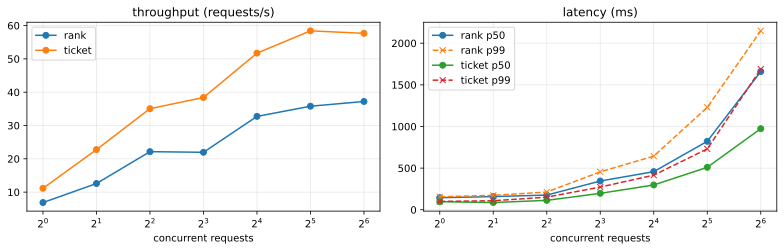

In [8]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ["svg"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for kind, g in bench.groupby("workload"):
    ax[0].plot(g.concurrency, g.req_per_s, "o-", label=kind)
    ax[1].plot(g.concurrency, g.e2e_p50_ms, "o-", label=f"{kind} p50")
    ax[1].plot(g.concurrency, g.e2e_p99_ms, "x--", label=f"{kind} p99")
for a, t in zip(ax, ("throughput (requests/s)", "latency (ms)")):
    a.set_xscale("log", base=2); a.set_xlabel("concurrent requests"); a.set_title(t); a.grid(alpha=.3); a.legend()
plt.tight_layout(); plt.show()

**How to read it:** throughput climbs while vLLM batches more requests per GPU step, then flattens once the GPU is
saturated; past that point extra concurrency only adds queueing latency. Pick the concurrency at the knee for your
latency budget, and use it as the per-instance autoscaling target.

## 8. Candidate count and the CLM vector cache
A `rank` call with N candidates embeds N+1 texts. CLM caches the embedding of every text it has seen, so an agent that
reuses its action set only pays for the new state. Below, each N is sent cold (all texts new) and then warm (same
candidates, new state).

In [9]:
pool = sorted({a for r in ranks for a in r["answers"]})
RUN = uuid.uuid4().hex[:8]       # fresh per run of this cell, so its "cold" requests are always cold
scale = []
for n in (8, 64, 256, 1024):
    cands = [f"[{RUN}-scale-{n}] {pool[i % len(pool)]} ({i})" for i in range(n)]
    cold = timed({"op": "rank", "context": f"[{RUN}-scale-{n}-a] A user asks for help.", "question": "What should the agent do?",
                  "answers": cands})
    warm = timed({"op": "rank", "context": f"[{RUN}-scale-{n}-b] A user asks for help.", "question": "What should the agent do?",
                  "answers": cands})
    scale.append({"candidates": n, "request_kb": len(json.dumps(cands)) / 1024,
                  "cold_ms": cold[1] * 1000, "warm_ms": warm[1] * 1000, "speed-up": cold[1] / warm[1]})
pd.DataFrame(scale)

,candidates,request_kb,cold_ms,warm_ms,speed-up
0,8,0.4,153.1,53.3,2.9
1,64,2.9,445.3,54.3,8.2
2,256,12.3,1556.9,55.4,28.1
3,1024,49.8,4514.3,66.0,68.4


## 9. Server-side metrics from Amazon CloudWatch
`ModelLatency` is time spent in the container; `OverheadLatency` is SageMaker's own share. GPU, CPU and memory
utilisation show which resource limits throughput. Metrics arrive with a 1-2 minute delay; the cell waits for them.

In [10]:
cw = session.client("cloudwatch")
time.sleep(150)
# The sweep starts on a minute boundary and the next traffic waits for one, so these minutes hold only the sweep.
window = (math.floor(bench_start / 60) * 60, math.ceil(bench_end / 60) * 60)

def metric(name, namespace, stat="Maximum"):
    """Aggregate the 1-minute datapoints over the benchmark window: the request-weighted mean for Average, the
    total for Sum, the highest minute for Maximum."""
    dims = [{"Name": "EndpointName", "Value": NAME}, {"Name": "VariantName", "Value": "AllTraffic"}]
    for d in (dims, dims + [{"Name": "InstanceType", "Value": INSTANCE_TYPE}]):   # pooled endpoints add InstanceType
        r = cw.get_metric_statistics(Namespace=namespace, MetricName=name, StartTime=window[0],
                                     EndTime=window[1], Period=60, Statistics=[stat, "SampleCount"], Dimensions=d)
        if points := r["Datapoints"]:
            if stat == "Average":
                return sum(p["Average"] * p["SampleCount"] for p in points) / sum(p["SampleCount"] for p in points)
            return sum(p["Sum"] for p in points) if stat == "Sum" else max(p[stat] for p in points)
    return float("nan")
server = pd.DataFrame([
    ("ModelLatency, average (ms)", metric("ModelLatency", "AWS/SageMaker", "Average") / 1000),
    ("OverheadLatency, average (ms)", metric("OverheadLatency", "AWS/SageMaker", "Average") / 1000),
    ("GPUUtilization, max (%)", metric("GPUUtilization", "/aws/sagemaker/Endpoints")),
    ("GPUMemoryUtilization, max (%)", metric("GPUMemoryUtilization", "/aws/sagemaker/Endpoints")),
    ("CPUUtilization, max (%, 100 per vCPU)", metric("CPUUtilization", "/aws/sagemaker/Endpoints")),
    ("MemoryUtilization, max (%)", metric("MemoryUtilization", "/aws/sagemaker/Endpoints")),
    ("Invocation5XXErrors, total", metric("Invocation5XXErrors", "AWS/SageMaker", "Sum")),
], columns=["metric", "value"])
server

,metric,value
0,"ModelLatency, average (ms)",646.8
1,"OverheadLatency, average (ms)",3.7
2,"GPUUtilization, max (%)",93.0
3,"GPUMemoryUtilization, max (%)",86.1
4,"CPUUtilization, max (%, 100 per vCPU)",76.3
5,"MemoryUtilization, max (%)",13.9
6,"Invocation5XXErrors, total",0.0


## 10. Cost per request
At the knee of each curve (the lowest concurrency within 2% of the best throughput, so not where only latency grows),
with one instance running all hour.

In [11]:
best = bench[bench.req_per_s >= 0.98 * bench.groupby("workload").req_per_s.transform("max")]
best = best.loc[best.groupby("workload").concurrency.idxmin()]
cost = best[["workload", "concurrency", "req_per_s", "e2e_p50_ms"]].assign(
    usd_per_million_requests=PRICE_PER_HOUR[INSTANCE_TYPE] / (best.req_per_s * 3600) * 1e6)
cost

,workload,concurrency,req_per_s,e2e_p50_ms,usd_per_million_requests
13,rank,64,37.2,1659.8,11.3
5,ticket,32,58.4,509.8,7.2


In [12]:
summary = {"instance": INSTANCE_TYPE, "price_per_hour": PRICE_PER_HOUR[INSTANCE_TYPE],
           "quality": {"rank_top1": rank_top1, "urgent_auroc": urgent_auroc, "department": dept_acc},
           "bench": bench.to_dict("records"), "scale": scale, "server": dict(server.values)}
def finite(x):
    """JSON has no NaN: a metric CloudWatch did not report is written as null."""
    if isinstance(x, dict):
        return {k: finite(v) for k, v in x.items()}
    if isinstance(x, list):
        return [finite(v) for v in x]
    x = x.item() if hasattr(x, "item") else x                      # NumPy scalars
    return None if isinstance(x, float) and math.isnan(x) else x

Path(f"results-{INSTANCE_TYPE}.json").write_text(json.dumps(finite(summary), indent=1, allow_nan=False))
print("saved", f"results-{INSTANCE_TYPE}.json")

saved results-ml.g5.2xlarge.json


## 11. Production next steps (optional)
* **Autoscaling.** Track `SageMakerVariantInvocationsPerInstance` (invocations per instance per minute), with the
  target taken from the measured peak in section 7 with 30% headroom. The next cell computes it per workload; the
  commented lines attach the policy. Size it for the workload you actually serve: `rank` saturates at a lower rate.
* **Scale to zero** for spiky or dev traffic: deploy the same model as an *inference component* with `MinInstanceCount=0`.
* **Fine-tuned heads** (e.g. the DeepSWE verifier heads) are another `*.pt` file: add it under `code/` and send
  `"model": "<file stem>"`; the engine serves every head it is given, on the same encoder.
* **Private networking:** add `VpcConfig` to `create_model` with an S3 gateway endpoint; network isolation already blocks egress.
* **Your data.** States and candidates often hold customer text (names, account numbers, health or payment details).
  You are responsible for handling it under the laws and standards that apply to you (for example GDPR, HIPAA or
  PCI DSS): encrypt the S3 artifact and the CloudWatch logs with your own KMS key (these GPU types encrypt their
  instance store in hardware, so their endpoint config takes no `KmsKeyId`), keep CloudWatch log retention
  short, and do not turn on data capture for regulated data without the controls it needs. The endpoint does not
  store request bodies; the handler logs only errors.

In [13]:
TARGET = {k: round(v * 60 * 0.7) for k, v in bench.groupby("workload").req_per_s.max().items()}
print("autoscaling target (invocations per instance per minute):", TARGET)
# aas = session.client("application-autoscaling")
# rid = f"endpoint/{NAME}/variant/AllTraffic"
# aas.register_scalable_target(ServiceNamespace="sagemaker", ResourceId=rid,
#                              ScalableDimension="sagemaker:variant:DesiredInstanceCount", MinCapacity=1, MaxCapacity=4)
# aas.put_scaling_policy(PolicyName=f"{NAME}-ipi", ServiceNamespace="sagemaker", ResourceId=rid,
#                        ScalableDimension="sagemaker:variant:DesiredInstanceCount", PolicyType="TargetTrackingScaling",
#                        TargetTrackingScalingPolicyConfiguration={"TargetValue": float(TARGET["rank"]),
#                            "PredefinedMetricSpecification": {"PredefinedMetricType": "SageMakerVariantInvocationsPerInstance"}})

autoscaling target (invocations per instance per minute): {'rank': 1563, 'ticket': 2454}


## 12. Clean up
Uncomment and run the helper cell, then part 1 to delete the endpoint (this stops billing), the endpoint config and the
model; that is all a redeploy needs. Part 2, run after part 1, also deletes the S3 artifact and weights, the logs and
the IAM role this notebook created. They need only the configuration cell (section 1) and the helper cell, so they work
after a kernel restart, and skip anything already gone. Neither touches local files: `build/` keeps the 16 GB
weight download for the next run, so delete it yourself (`shutil.rmtree("build")`) when you are done.

In [14]:
# def gone(call, **kw):
#     """Delete one resource. One that is already gone is fine; any other error (access, throttling) stops here."""
#     try:
#         call(**kw)
#     except ClientError as e:
#         err = e.response["Error"]
#         if not (err["Code"] in ("NoSuchEntity", "ResourceNotFoundException", "ObjectNotFoundException", "NoSuchKey",
#                                 "NoSuchBucket")
#                 or (err["Code"] == "ValidationException" and "Could not find" in err.get("Message", ""))):
#             raise
#         print("already gone:", kw)

In [15]:
# # Part 1: the endpoint, endpoint config and model (all a redeploy or a capacity retry needs removed), each only
# # if it carries this notebook's tag, so a same-named resource someone else created is kept.
# def ours(describe_call, arn_key, **kw):
#     try:
#         return ROLE_TAG in sm.list_tags(ResourceArn=describe_call(**kw)[arn_key])["Tags"]
#     except ClientError as e:            # missing: nothing to delete; any other error (access, throttling) stops here
#         if "Could not find" not in e.response["Error"].get("Message", ""):
#             raise
#         return False
# if ours(sm.describe_endpoint, "EndpointArn", EndpointName=NAME):
#     gone(sm.delete_endpoint, EndpointName=NAME)                # first, so billing stops whatever happens next
#     sm.get_waiter("endpoint_deleted").wait(EndpointName=NAME)   # its last log lines must land before the log group goes
#     try:                                # the autoscaling target, if section 11 attached one (needs its own permission)
#         session.client("application-autoscaling").deregister_scalable_target(ServiceNamespace="sagemaker",
#             ResourceId=f"endpoint/{NAME}/variant/AllTraffic", ScalableDimension="sagemaker:variant:DesiredInstanceCount")
#     except ClientError as e:
#         print("autoscaling target:", e.response["Error"]["Code"])
# if ours(sm.describe_endpoint_config, "EndpointConfigArn", EndpointConfigName=NAME):
#     gone(sm.delete_endpoint_config, EndpointConfigName=NAME)
# if ours(sm.describe_model, "ModelArn", ModelName=NAME):
#     gone(sm.delete_model, ModelName=NAME)
# print("part 1 done (anything of that name not created by this notebook was kept)")

In [16]:
# # Part 2: the S3 artifact, logs and role. Only what this notebook wrote: the weights prefix and the artifact prefixes for this revision pair, every version
# # included (on a versioned bucket, deleting only the current objects would leave 16 GB billing).
# try:                                   # our live endpoint still needs these files to replace an instance
#     if ROLE_TAG in sm.list_tags(ResourceArn=sm.describe_endpoint(EndpointName=NAME)["EndpointArn"])["Tags"]:
#         raise SystemExit(f"{NAME} still exists: run part 1 first")
# except ClientError as e:
#     if "Could not find" not in e.response["Error"].get("Message", ""):
#         raise
# our_prefixes = (WEIGHTS, f"clm-8b/{ENCODER_REV[:8]}-{HEADS_REV[:8]}-")
# try:
#     for p in s3.get_paginator("list_object_versions").paginate(Bucket=BUCKET, Prefix="clm-8b/", ExpectedBucketOwner=account):
#         objs = [{"Key": v["Key"], "VersionId": v["VersionId"]} for v in p.get("Versions", []) + p.get("DeleteMarkers", [])
#                 if v["Key"].startswith(our_prefixes)]
#         if objs:
#             r = s3.delete_objects(Bucket=BUCKET, ExpectedBucketOwner=account, Delete={"Objects": objs})
#             if r.get("Errors"):
#                 raise RuntimeError(f"{len(r['Errors'])} S3 objects were not deleted: {r['Errors'][:3]}")
# except ClientError as e:
#     if e.response["Error"]["Code"] != "NoSuchBucket":
#         raise
#     print("already gone:", BUCKET)
# gone(session.client("logs").delete_log_group, logGroupName=f"/aws/sagemaker/Endpoints/{NAME}")
# iam = session.client("iam")
# try:
#     role_is_ours = ROLE_TAG in iam.list_role_tags(RoleName=ROLE_NAME)["Tags"]      # only the role this notebook created
# except iam.exceptions.NoSuchEntityException:
#     role_is_ours = False
# if role_is_ours:
#     gone(iam.delete_role_policy, RoleName=ROLE_NAME, PolicyName="clm-8b-endpoint")
#     gone(iam.delete_role_policy, RoleName=ROLE_NAME, PolicyName="clm-8b-kms")
#     gone(iam.delete_role, RoleName=ROLE_NAME)
# print("clean-up done")